# 1. Introdução

# 2. Contexto do Problema de Negócio

# 3. Descrição da Base de Dados

# 4. Variável Target

# 5. Importação de Bibliotecas e Configurações Iniciais

In [37]:
# BIBLIOTECAS IMPORTADAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as sts

# 6. Carregamento dos Dados

In [38]:
# CARREGAMENTO DO DATASET
application_train = pd.read_csv('../data/application_train.csv', encoding = 'iso-8859-1')

# 7. Visão Geral do Dados

In [39]:
print('Formato do dataset (LinhasxColunas):{}\n'.format(application_train.shape))
print('Tipo das variáveis presentes no dataset: \n{}\n'.format(application_train.dtypes.unique()))
print('Informações Geral do dataset:')
application_train.info()
application_train.head(10)

Formato do dataset (LinhasxColunas):(307511, 122)

Tipo das variáveis presentes no dataset: 
[dtype('int64') dtype('O') dtype('float64')]

Informações Geral do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


# 8. Análise da Variável Target

Tipo do TARGET: int64
Quantidade total do TARGET: 307,511.00
Percentil das categorias do Target: TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


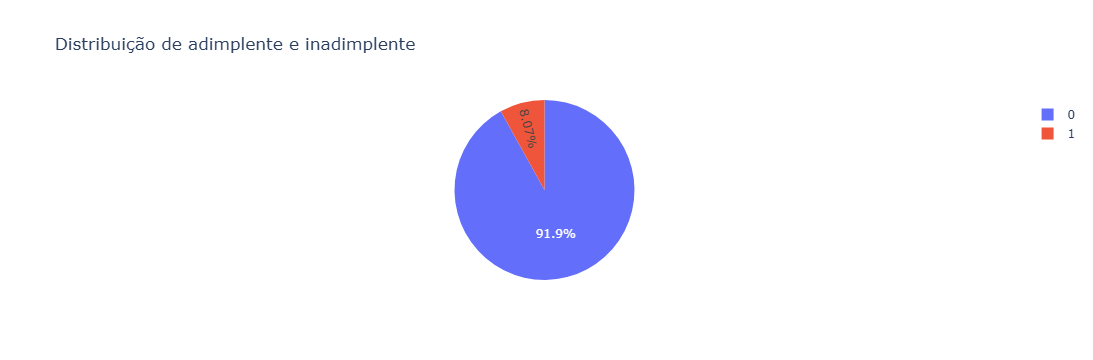

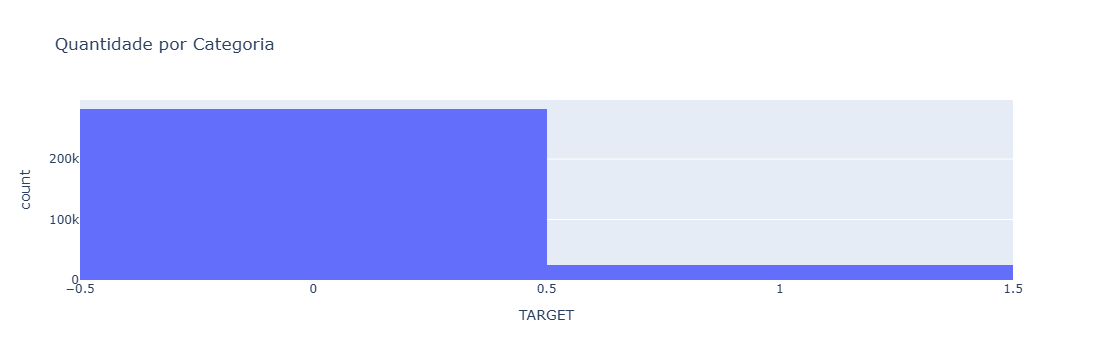

In [43]:
print('Tipo do TARGET: {}'.format(application_train['TARGET'].dtype))
print('Quantidade total do TARGET: {:,.2f}'.format(application_train['TARGET'].value_counts().sum()))
print('Percentil das categorias do Target: {}'.format(application_train['TARGET'].value_counts(normalize = True) * 100))
display(px.pie(application_train, 'TARGET', title = 'Distribuição de adimplente e inadimplente'))
display(px.histogram(application_train, x = 'TARGET', title = 'Quantidade por Categoria'))

## Interpretação da Variável TARGET

A análise da variável TARGET evidencia um forte desbalanceamento entre as classes.
Do total de aproximadamente 307 mil registros, cerca de 91,9% correspondem a clientes
adimplentes (TARGET = 0), enquanto aproximadamente 8,1% representam clientes
inadimplentes (TARGET = 1).

Esse comportamento é esperado em bases de dados utilizadas para concessão de crédito,
uma vez que eventos de inadimplência tendem a ser significativamente menos frequentes
do que pagamentos em dia.

O forte desbalanceamento observado indica que métricas tradicionais como acurácia
não serão adequadas para avaliar o desempenho dos modelos preditivos.
Dessa forma, será necessário utilizar métricas mais apropriadas ao contexto de
risco de crédito, como AUC-ROC, Recall da classe inadimplente e métricas focadas
na separação entre bons e maus pagadores.

# 9. Análise de Valores Ausentes (Missing Values)

In [94]:
# EXTRAI AS FEATURES COM QUALQUER VALORE NULO PRESENTE 
application_null = application_train.loc[:, application_train.isna().any()]

# EXTRAI OS REGISTROS DAS FEATURES ONDE POSSUI VALOR NULO PRESENTE
missing_value = application_null[application_null.isna().any(axis = 1)]

# QUANTIDADE TOTAL DE REGISTROS, QUANTIDADE DE VALORES NULOS, PROPORÇÃO DE NULOS
total_registros = len(application_train)
total_nulos = missing_value.isna().sum().sum()
proporcao_nulos = (missing_value.isna().sum().sum() / missing_value.size) * 100


# RESULTADOS ALCANÇADOS
print('Quantidade Total Registros: {:,.2f}'.format(total_registros))
print('Quantidade de Valores Nulos: {:,.2f}'.format(total_nulos))
print('Proporção de Valores Nulos: {:.2f}%'.format(proporcao_nulos))

Quantidade Total Registros: 307,511.00
Quantidade de Valores Nulos: 9,152,465.00
Proporção de Valores Nulos: 45.70%


## Visão Global (Macro)

Observa-se que o dataset apresente um volume elevado de valores ausentes. Do total de aproximadamente 307 mil registros e 122 variaveis,
cerca de 45% das observações póssiveis encontram-se com valores nulos.

Esse comportamento é esperado em bases de risco de crédito, uma vez que nem todas as informações são aplicáveis a todos os perfis de cliente ou estão disponíveis no momento da concesão

In [148]:
# CRIA O DATAFRAME COM O PERCENTUAL E VARIAVL
missing_df = application_train.isna().mean().sort_values(ascending=False).reset_index()
missing_df.columns = ['Variavel', 'Percentual_Nulos']

# CRIA O DATAFRAME COM A QUANTIDADE DE NULOS
soma_nulos = application_train.isna().sum()
coluna_nulos = soma_nulos.to_frame().reset_index()
coluna_nulos.columns = ['Variavel', 'Quantidade_Nulos']

# JUNTA OS DOIS DATAFRAMES PELA COLUNA 'VARIAVEL'
dataset_final = pd.merge(coluna_nulos, missing_df, on='Variavel')

# FILTRA PARA TRAZER APENAS QUEM TEM NULOS E ORDENA DO MAIOR PARA O MENOR
dataset_final = dataset_final[dataset_final['Quantidade_Nulos'] > 0]
dataset_final = dataset_final.sort_values(by='Quantidade_Nulos', ascending=False).reset_index(drop=True)

# EXIBE O RESULTADO FINAL
dataset_final


,Variavel,Quantidade_Nulos,Percentual_Nulos
0,COMMONAREA_MEDI,214865,0.698723
1,COMMONAREA_AVG,214865,0.698723
2,COMMONAREA_MODE,214865,0.698723
3,NONLIVINGAPARTMENTS_MEDI,213514,0.694330
4,NONLIVINGAPARTMENTS_MODE,213514,0.694330
...,...,...,...
62,EXT_SOURCE_2,660,0.002146
63,AMT_GOODS_PRICE,278,0.000904
64,AMT_ANNUITY,12,0.000039
65,CNT_FAM_MEMBERS,2,0.000007


In [165]:
# PERCENTUAL DE MISSING 0% - 5%
baixo_impacto = dataset_final[dataset_final['Percentual_Nulos'] <= 0.05].reset_index(drop = True)
baixo_impacto

# PERCENTUAL DE MISSING 5% - 30%
atencao = dataset_final[(dataset_final['Percentual_Nulos'] > 0.05) & (dataset_final['Percentual_Nulos'] <= 0.30)].reset_index(drop = True)
atencao

# PERCENTUAL DE MISSING 30% - 60%
alto_risco = dataset_final[(dataset_final['Percentual_Nulos'] > 0.30) & (dataset_final['Percentual_Nulos'] <= 0.60)].reset_index(drop = True)
alto_risco

# PERCENTUAL DE MISSING >= 60%
candidato_descarte  = dataset_final[dataset_final['Percentual_Nulos'] >= 0.60].reset_index(drop = True)
candidato_descarte

print('Quantidades total de missing em cada faixa: \nBaixo_Risco: {} \nAtenção: {}\nAlto_Risco: {}\nCandidato a Descarte: {}\n'.format(len(baixo_impacto),len(atencao), len(alto_risco), len(candidato_descarte) ))

Quantidades total de missing em cada faixa: 
Baixo_Risco: 10 
Atenção: 7
Alto_Risco: 33
Candidato a Descarte: 17



## Visão micro dos valores ausentes

Observado na análise mais detalhada de missing values, as features com qualquer valor missing presente em seus registros foram divididas em 4 grupos distintos, esses grupos tem como caracteristica, classificar a variavel baseado na sua porcentagem de nulos proporcional ao total de observações
Do total de 67 features com valores missing presente em seus registros, 
- **Baixo Risco (0% - 5%)**: 10 Features
- **Atenção (5% - 30%)**: 7 Features
- **Alto Risco (30% - 60%)**: 33 Features
- **Candidato à Descarte (>= 60%)**: 17 Features

As faixas são definidas pela proporção de valores nulos que cada feature tem, sendo:
- **Baixo Risco**: Missing Pontual, Pouco Impacto na Modelagem, Tratamento simples no futuro
- **Atenção**: Missing Relevante, Exige Análise individual no feature engineering, Podem Carregar alguma informação 
- **Alto Risco**: Missing elevado, muitas vezes ocasionado à não aplicabilidade, Avaliação cuidadosa antes de manter
- **Candidato à Descarte**: Missing Extremo, Alto rísco de Ruído, Só mantidas se forem claramente informativas, caso contrário, forte candidata a exclusão.


**OWN_CAR_AGE** - Candidato a Descarte
- Essa variavel apresenta elevado percentual de valores ausentes devido à não posse de veículo por parte dos clientes. Embora o missing seja informativo, o uso direto da variável pode gerar viés, sendo mais adequado explorar a informação por meio de uma flag indicativa de posse de veículo. Será descartada ou transformada em flag

**APARTAMENTS_MODE** - Alto Risco:
- O elevado percentual de valores ausentes está associado tanto à não posse de imóvel quanto à ausência de informação declarada. Apesar do alto nível de missing, a variável pode carregar sinal socioeconômico relevante, devendo ser avaliada com cautela na etapa de feature engeneering. Será mantida para avaliação futura, possivelmente como flag.

**AMT_REQ_CREDIT_BUREAU_WEEK** - Atenção
- A ausência de registros pode indicar inexistência de consultas recentes ao birô de crédito, o quer por si só pode ser informativo. Trata-se de uma variável potencialmente relevante para o risco de crédito, devendo ser mantida e analisada em conjunto com outras variáveis de histórico extermo. Manter, missing pode ser informativo.

**Diretrizes para o Pipeline**
- Features pertencente ao grupo 'Candidato a Descarte' -> serão avaliadas paa serem descartadas
- Missimg por não aplicabilidade -> Criação de flags
- Missing potencialmente informativo -> manter e tratar
- Estratégias de imputação -> Definidas na fase de modelagem

# 10. Análise de Variáveis Numéricas

# 11.  Análise das Variáveis Categóricas

# 12. Principais Insights da Análise Exploratória

# 13. Próximo Passos